Georgia -> N: 2380 | Median: $25.00 | Floor: $7.25 | Kaitz Index: 0.290
Maine   -> N: 850  | Median: $26.65 | Floor: $14.65 | Kaitz Index: 0.550


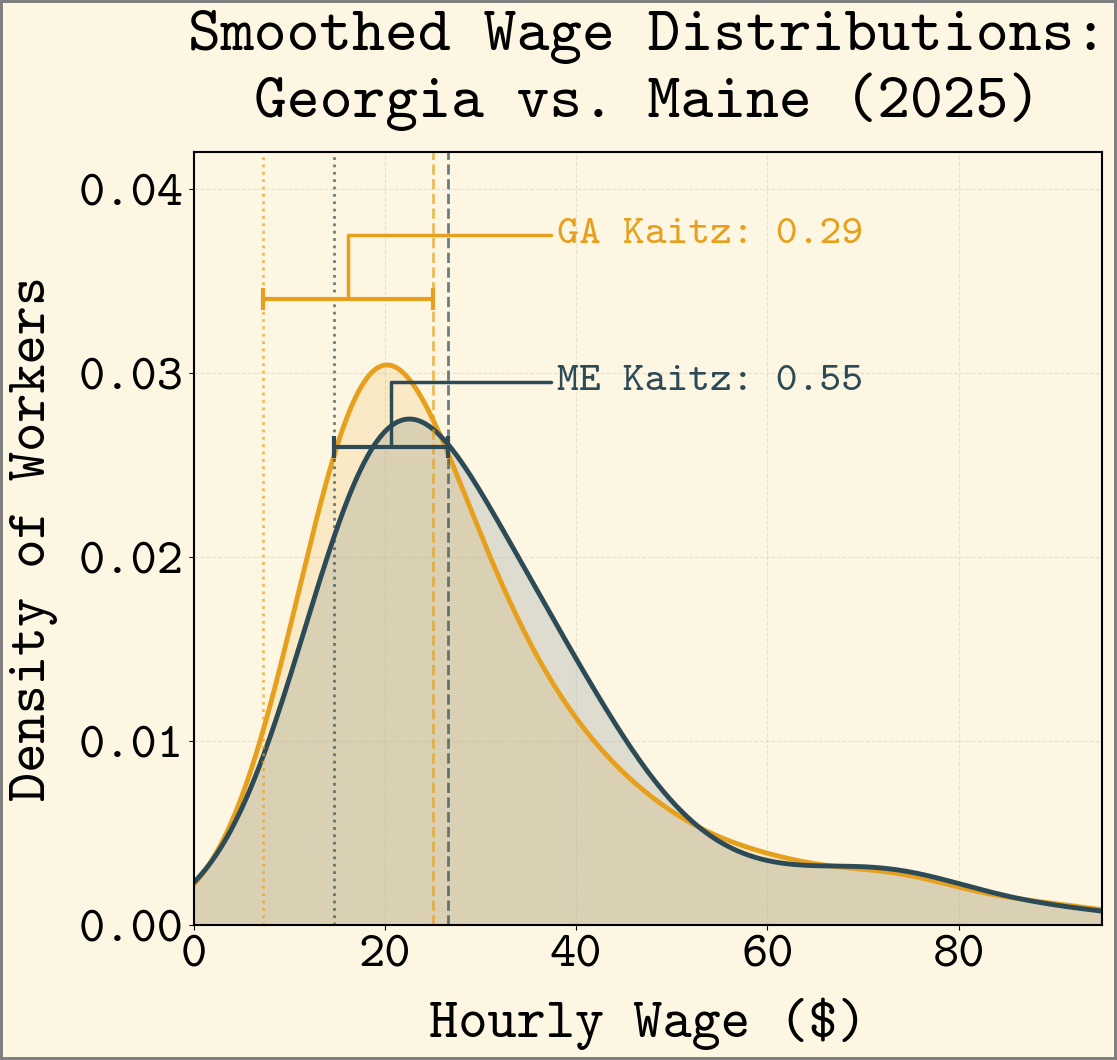

In [48]:
# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ---------------------------------------------------------
# 1. Load Data & Filter (Georgia & Maine)
# ---------------------------------------------------------
target_cols = ['statefips', 'wage', 'orgwgt', 'emp']
df = pd.read_stata('epi_cpsorg_2025.dta', columns=target_cols)

# Filter for employed workers with valid wages in GA or ME
df_clean = df[
    (df['emp'] == 'Employed') & 
    (df['wage'].notna()) & 
    (df['wage'] > 0) & 
    (df['statefips'].isin(['GA', 'ME']))
].copy()

# ---------------------------------------------------------
# 2. Weighted Median Function
# ---------------------------------------------------------
def get_weighted_median(data, val_col='wage', weight_col='orgwgt'):
    sorted_df = data.sort_values(val_col)
    cumsum = sorted_df[weight_col].cumsum()
    cutoff = sorted_df[weight_col].sum() / 2.0
    return sorted_df[cumsum >= cutoff][val_col].iloc[0]

# Slice state subsets
ga_data = df_clean[df_clean['statefips'] == 'GA']
me_data = df_clean[df_clean['statefips'] == 'ME']

# Calculate medians
ga_median = get_weighted_median(ga_data)
me_median = get_weighted_median(me_data)

# 2025 Statutory minimum wage floors
ga_floor = 7.25    # Federal floor default
me_floor = 14.65   # Maine state statutory floor

# Kaitz Indices
ga_kaitz = ga_floor / ga_median
me_kaitz = me_floor / me_median

print(f"Georgia -> N: {len(ga_data)} | Median: ${ga_median:.2f} | Floor: ${ga_floor:.2f} | Kaitz Index: {ga_kaitz:.3f}")
print(f"Maine   -> N: {len(me_data)}  | Median: ${me_median:.2f} | Floor: ${me_floor:.2f} | Kaitz Index: {me_kaitz:.3f}")

# %%
# ---------------------------------------------------------
# 3. Fit Weighted KDEs
# ---------------------------------------------------------
x_grid = np.linspace(0, 100, 1000)

kde_ga = gaussian_kde(ga_data['wage'], weights=ga_data['orgwgt'])
kde_me = gaussian_kde(me_data['wage'], weights=me_data['orgwgt'])

y_ga = kde_ga(x_grid)
y_me = kde_me(x_grid)

# ---------------------------------------------------------
# 4. Canvas & Base Plotting Setup
# ---------------------------------------------------------
plt.style.use('btt_style')

fig, ax = plt.subplots(figsize=(12, 11))

# Add explicit margin padding: [left, bottom, right, top] in inches
fig.set_constrained_layout_pads(w_pad=0.3, h_pad=0.3, wspace=0.0, hspace=0.0)
fig.get_layout_engine().set(rect=(0, 0, 0.96, 1))  # Pulls the right boundary inward

color_ga = '#E6A01D'  # Warm gold/amber
color_me = '#2C4B57'  # BTT Slate/Navy

# Density Curves
ax.plot(x_grid, y_ga, color=color_ga, linewidth=3.5)
ax.fill_between(x_grid, y_ga, color=color_ga, alpha=0.15)

ax.plot(x_grid, y_me, color=color_me, linewidth=3.5)
ax.fill_between(x_grid, y_me, color=color_me, alpha=0.15)

# Reference Lines: Floors & Medians
ax.axvline(ga_floor, color=color_ga, linestyle=':', linewidth=2, alpha=0.7)
ax.axvline(ga_median, color=color_ga, linestyle='--', linewidth=2, alpha=0.7)

ax.axvline(me_floor, color=color_me, linestyle=':', linewidth=2, alpha=0.7)
ax.axvline(me_median, color=color_me, linestyle='--', linewidth=2, alpha=0.7)

# ---------------------------------------------------------
# 5. Horizontal Capped Range Bars & Right-Facing "L" Callouts
# ---------------------------------------------------------
# Georgia Bracket Bar
ga_center_x = (ga_floor + ga_median) / 2.0
ga_err = (ga_median - ga_floor) / 2.0
ga_bar_y = 0.034

ax.errorbar(
    ga_center_x, ga_bar_y, xerr=ga_err,
    color=color_ga, elinewidth=3, capsize=8, capthick=3, fmt='none'
)

# Georgia "L" Callout
ax.annotate(
    f'GA Kaitz: {ga_kaitz:.2f}',
    xy=(ga_center_x, ga_bar_y),
    xytext=(38, ga_bar_y + 0.0035),
    color=color_ga,
    fontsize=30,
    weight='bold',
    ha='left',
    va='center',
    arrowprops=dict(
        arrowstyle='-',
        color=color_ga,
        linewidth=2.5,
        connectionstyle='angle,angleA=0,angleB=90,rad=0'
    )
)

# Maine Bracket Bar
me_center_x = (me_floor + me_median) / 2.0
me_err = (me_median - me_floor) / 2.0
me_bar_y = 0.026

ax.errorbar(
    me_center_x, me_bar_y, xerr=me_err,
    color=color_me, elinewidth=3, capsize=8, capthick=3, fmt='none'
)

# Maine "L" Callout
ax.annotate(
    f'ME Kaitz: {me_kaitz:.2f}',
    xy=(me_center_x, me_bar_y),
    xytext=(38, me_bar_y + 0.0035),
    color=color_me,
    fontsize=30,
    weight='bold',
    ha='left',
    va='center',
    arrowprops=dict(
        arrowstyle='-',
        color=color_me,
        linewidth=2.5,
        connectionstyle='angle,angleA=0,angleB=90,rad=0'
    )
)

# ---------------------------------------------------------
# 6. Axis Formatting & Output
# ---------------------------------------------------------
ax.set_title('Smoothed Wage Distributions:\nGeorgia vs. Maine (2025)', pad=25)
ax.set_xlabel('Hourly Wage ($)', labelpad=15)
ax.set_ylabel('Density of Workers', labelpad=15)
ax.set_xlim(0, 95)
ax.set_ylim(0, max(max(y_ga), max(y_me)) * 1.38)
ax.grid(True, alpha=0.3)

# Force outer border thickness
fig.patch.set_linewidth(4)

fig.savefig("wage_dist_ga_vs_me.png")
plt.show()